# 02 - Agent Action Distribution
Owner: Shreya + Shravani

Checks:
- action distributions per agent over a rollout
- whether agents are exploring all 3 actions
- per-agent reward comparison
- trust scores across agents

NOTE: run this after at least one training run or with random policy to baseline

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from collections import defaultdict
import sys
import os

sys.path.insert(0, os.path.abspath('..'))

from env.ran_env import RANEnv
from agents.agent_manager import AgentManager

# constants
NUM_CELLS = 7
OBS_DIM = 16
ACTION_LABELS = ['STAY', 'PREPARE_HO', 'TRIGGER_HO']

env = RANEnv(num_cells=NUM_CELLS, num_ues=10)
manager = AgentManager(num_agents=NUM_CELLS, obs_dim=OBS_DIM)
agent_ids = env.possible_agents

# IMPORTANT: to test trained policy, load checkpoint below
# manager.load_checkpoint('../results/checkpoints/final')
print('Setup complete')

Setup complete


In [3]:
# rollout
obs_dict, _ = env.reset(seed=42)

action_counts = defaultdict(lambda: [0, 0, 0])   # {agent_id: [stay, prep, trigger]}
reward_per_agent = defaultdict(list)

for step in range(200):
    obs_list = [obs_dict[a] for a in agent_ids]
    actions, _, _ = manager.select_actions(obs_list)
    actions_dict = {agent_ids[i]: actions[i] for i in range(NUM_CELLS)}

    obs_dict, rewards, terminations, truncations, info = env.step(actions_dict)

    for i, agent in enumerate(agent_ids):
        action_counts[agent][actions[i]] += 1
        reward_per_agent[agent].append(rewards[agent])

    if all(truncations.get(a, False) for a in agent_ids):
        break

print('Rollout complete')

Rollout complete


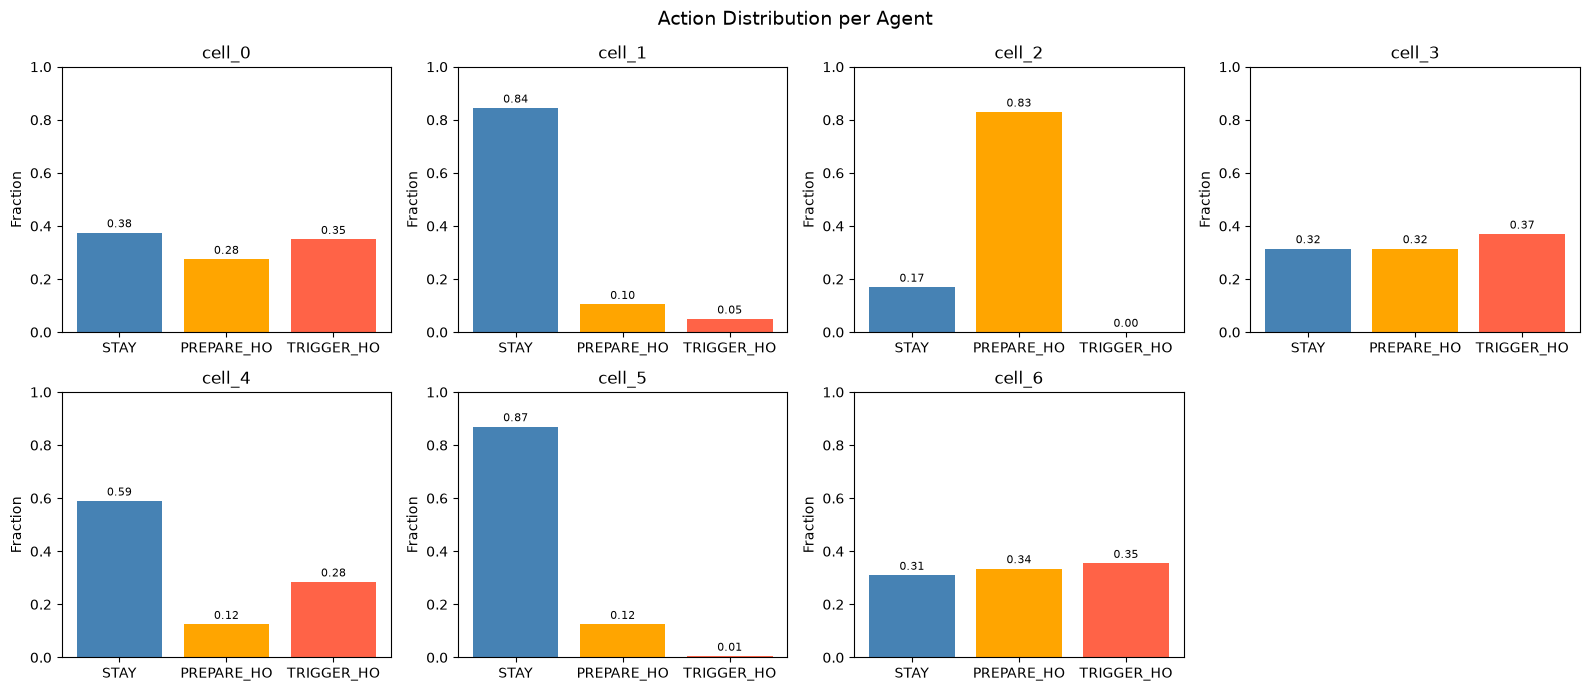

In [4]:
# plot: action distribution per agent
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, agent in enumerate(agent_ids):
    counts = action_counts[agent]
    total = sum(counts)
    fracs = [c / total for c in counts]
    bars = axes[i].bar(ACTION_LABELS, fracs, color=['steelblue', 'orange', 'tomato'])
    axes[i].set_title(agent)
    axes[i].set_ylim(0, 1)
    axes[i].set_ylabel('Fraction')
    for bar, frac in zip(bars, fracs):
        axes[i].text(bar.get_x() + bar.get_width()/2, frac + 0.02,
                     f'{frac:.2f}', ha='center', fontsize=8)

# hide unused subplot
axes[-1].set_visible(False)

plt.suptitle('Action Distribution per Agent', fontsize=14)
plt.tight_layout()
plt.savefig('../results/plots/action_distribution.png', dpi=150)
plt.show()

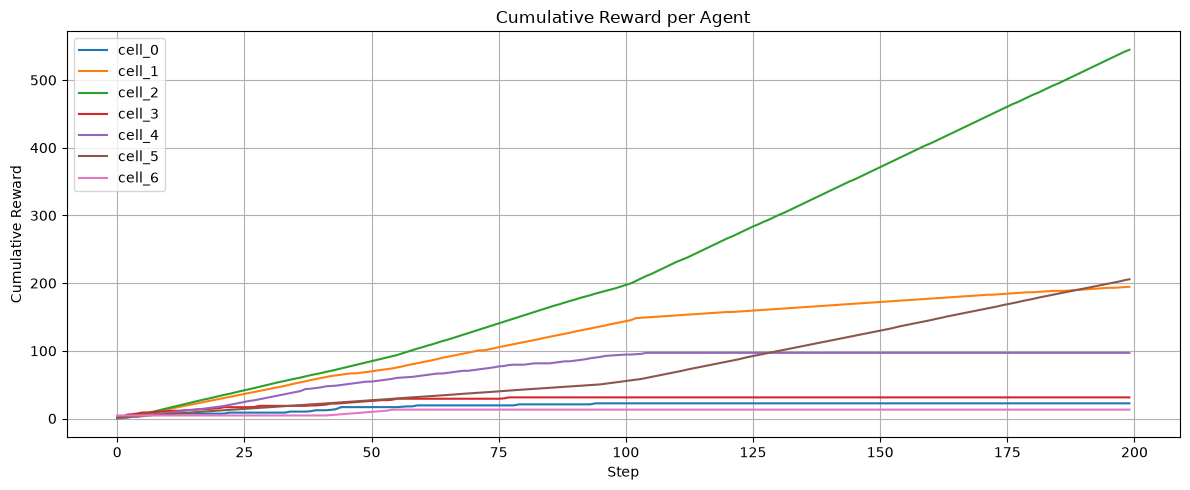

In [5]:
# plot: cumulative reward per agent
plt.figure(figsize=(12, 5))
for agent in agent_ids:
    cumulative = np.cumsum(reward_per_agent[agent])
    plt.plot(cumulative, label=agent)

plt.title('Cumulative Reward per Agent')
plt.xlabel('Step')
plt.ylabel('Cumulative Reward')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../results/plots/cumulative_reward.png', dpi=150)
plt.show()

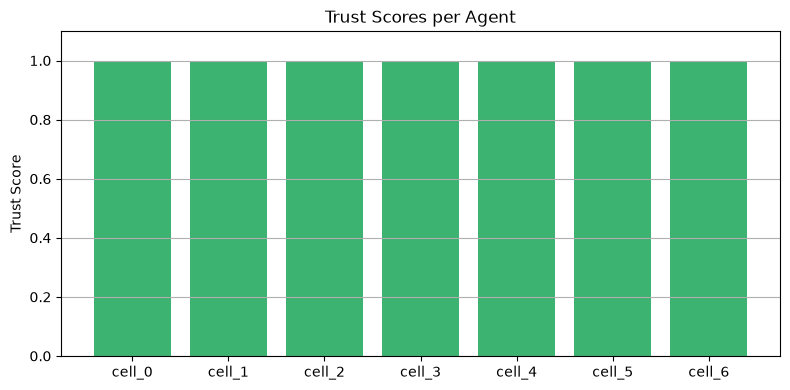

Trust scores: {'cell_0': 1.0, 'cell_1': 1.0, 'cell_2': 1.0, 'cell_3': 1.0, 'cell_4': 1.0, 'cell_5': 1.0, 'cell_6': 1.0}


In [6]:
# trust scores
# trust scores initialized to 1.0, should still be 1.0 here
# after consensus integration, scores will diverge
trust_scores = manager.get_trust_scores()

plt.figure(figsize=(8, 4))
plt.bar(agent_ids, trust_scores, color='mediumseagreen')
plt.title('Trust Scores per Agent')
plt.ylabel('Trust Score')
plt.ylim(0, 1.1)
plt.grid(axis='y')
plt.tight_layout()
plt.savefig('../results/plots/trust_scores.png', dpi=150)
plt.show()

print('Trust scores:', dict(zip(agent_ids, trust_scores)))